In [344]:
import pandas as pd 
import numpy as np 
import re

In [345]:
store = pd.read_csv("store_info.csv")  
sales = pd.read_csv("sales_transactions.csv")

In [346]:
store.head()

,store_id,region,manager,store_size,store_type,opening_year
0,S01,East,Manager_A,Medium,Street,2020
1,S02,South,Manager_B,Medium,Street,2017
2,S03,North,Manager_C,Large,Street,2020
3,Store-04,E,Manager_D,Large,Street,2009
4,S05,East,Manager_E,Small,Mall,2022


In [347]:
sales.head()

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost
0,T000571,S06,2025-06-27 00:00:00,Sports,2,activepro,East,59.53,121.7,31,2.76,73.19 CAD
1,T000763,S18,2025-02-14 00:00:00,Beauty,2,Glow Works,West,17.62,40.84,10,NaN,119.32
2,T000623,S03,NaN,Electronics,1,NORTHSTAR,North,235.26,308.8,145,4.66,103.05
3,T000827,S27,2025-01-06 00:00:00,Grocery,2,FreshFarm,West,6.41,10.74,14,4.56,125.6
4,T000175,S01,2025-05-06 00:00:00,Electronics,8,NorthStar,East,231.33,289.13,48,5.34,113.35


In [348]:
print(sales.shape)

(3085, 12)


In [349]:
print(store.shape)

(30, 6)


In [350]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3085 entries, 0 to 3084
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    3085 non-null   object
 1   store_id          3085 non-null   object
 2   sale_date         3066 non-null   object
 3   product_category  3085 non-null   object
 4   quantity          3060 non-null   object
 5   supplier          3085 non-null   object
 6   region            3085 non-null   object
 7   unit_cost         3032 non-null   object
 8   unit_price        3085 non-null   object
 9   inventory_level   3046 non-null   object
 10  labour_hours      3053 non-null   object
 11  labour_cost       3085 non-null   object
dtypes: object(12)
memory usage: 289.3+ KB


In [351]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   store_id      30 non-null     object
 1   region        30 non-null     object
 2   manager       30 non-null     object
 3   store_size    30 non-null     object
 4   store_type    30 non-null     object
 5   opening_year  30 non-null     int64 
dtypes: int64(1), object(5)
memory usage: 1.5+ KB


In [352]:
# I create a variable to count the number of duplicates
remove_duplicate = int(sales.duplicated().sum())
print(remove_duplicate)

85


In [353]:
# Here I remove those duplicates from the dataset
sales = sales.drop_duplicates().copy()
print(sales.shape)

(3000, 12)


In [354]:
# I convert quantity to numeric
sales["quantity"] = pd.to_numeric(sales["quantity"], errors="coerce")

# Then I count missing data
missing_quantity_count = int(sales["quantity"].isna().sum())

# Find values zero and negative quantities because those are invalid since 0 would mean nothing is sold and negative is 
# not possible
invalid_quantity = (
    sales["quantity"].notna() &
    (sales["quantity"] <= 0)
)

# Calculate the total invalid quantity count
invalid_quantity_count = (
    missing_quantity_count +
    int(invalid_quantity.sum())
)

# Replace negative quantities with NA
sales.loc[invalid_quantity, "quantity"] = np.nan

# Keep quantity as whole numbers while allowing NA
sales["quantity"] = sales["quantity"].astype("Int64")

print(invalid_quantity_count)

sales = sales.replace(r"^\s*$", np.nan, regex=True)
sales = sales.replace(["unknown", "Unknown", "UNKNOWN"], np.nan)

120


In [355]:
# this is for cleaning the ids and stuff because it is messy right now; it is S05, Store-04, store_20; I want to make it S05 format

def clean_store_id(x):
    if pd.isna(x): 
        return pd.NA
    
    s = str(x).strip().upper()
   
    digits = "".join(re.findall(r"\d+", s))
    
    if digits == "": 
        return pd.NA

    return "S" + digits.zfill(2)

sales["store_id"] = sales["store_id"].apply(clean_store_id)
store["store_id"] = store["store_id"].apply(clean_store_id)
    


In [356]:
sales.head()

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost
0,T000571,S06,2025-06-27 00:00:00,Sports,2,activepro,East,59.53,121.7,31,2.76,73.19 CAD
1,T000763,S18,2025-02-14 00:00:00,Beauty,2,Glow Works,West,17.62,40.84,10,NaN,119.32
2,T000623,S03,NaN,Electronics,1,NORTHSTAR,North,235.26,308.8,145,4.66,103.05
3,T000827,S27,2025-01-06 00:00:00,Grocery,2,FreshFarm,West,6.41,10.74,14,4.56,125.6
4,T000175,S01,2025-05-06 00:00:00,Electronics,8,NorthStar,East,231.33,289.13,48,5.34,113.35


In [357]:
store.head()

,store_id,region,manager,store_size,store_type,opening_year
0,S01,East,Manager_A,Medium,Street,2020
1,S02,South,Manager_B,Medium,Street,2017
2,S03,North,Manager_C,Large,Street,2020
3,S04,E,Manager_D,Large,Street,2009
4,S05,East,Manager_E,Small,Mall,2022


In [358]:
# This step I cleaned supplier names 

supplier_map = {

    "northstar":"NorthStar",

    "activepro":"ActivePro",
    "active pro":"ActivePro",

    "glowworks":"GlowWorks",
    "glow works":"GlowWorks",

    "freshfarm":"FreshFarm",

    "budgetsource":"BudgetSource",

    "stylehub":"StyleHub"

}

supplier_lower = (
    sales["supplier"]
    .astype("string")
    .str.strip()
    .str.lower()
)

sales["supplier"] = supplier_lower.map(supplier_map)


In [359]:
sales.head()

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost
0,T000571,S06,2025-06-27 00:00:00,Sports,2,ActivePro,East,59.53,121.7,31,2.76,73.19 CAD
1,T000763,S18,2025-02-14 00:00:00,Beauty,2,GlowWorks,West,17.62,40.84,10,NaN,119.32
2,T000623,S03,NaN,Electronics,1,NorthStar,North,235.26,308.8,145,4.66,103.05
3,T000827,S27,2025-01-06 00:00:00,Grocery,2,FreshFarm,West,6.41,10.74,14,4.56,125.6
4,T000175,S01,2025-05-06 00:00:00,Electronics,8,NorthStar,East,231.33,289.13,48,5.34,113.35


In [360]:
# Here I am cleaning the product categories 

sales["product_category"] = (
    sales["product_category"]
    .astype("string")
    .str.strip()
    .str.title()
)

In [361]:
sales.head()

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost
0,T000571,S06,2025-06-27 00:00:00,Sports,2,ActivePro,East,59.53,121.7,31,2.76,73.19 CAD
1,T000763,S18,2025-02-14 00:00:00,Beauty,2,GlowWorks,West,17.62,40.84,10,NaN,119.32
2,T000623,S03,NaN,Electronics,1,NorthStar,North,235.26,308.8,145,4.66,103.05
3,T000827,S27,2025-01-06 00:00:00,Grocery,2,FreshFarm,West,6.41,10.74,14,4.56,125.6
4,T000175,S01,2025-05-06 00:00:00,Electronics,8,NorthStar,East,231.33,289.13,48,5.34,113.35


In [362]:
# this is for cleaning dates
sales["sale_date"] = pd.to_datetime(
    sales["sale_date"],
    errors = "coerce", 
    format = "mixed"
) 

In [363]:
sales.head()

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost
0,T000571,S06,2025-06-27,Sports,2,ActivePro,East,59.53,121.7,31,2.76,73.19 CAD
1,T000763,S18,2025-02-14,Beauty,2,GlowWorks,West,17.62,40.84,10,NaN,119.32
2,T000623,S03,NaT,Electronics,1,NorthStar,North,235.26,308.8,145,4.66,103.05
3,T000827,S27,2025-01-06,Grocery,2,FreshFarm,West,6.41,10.74,14,4.56,125.6
4,T000175,S01,2025-05-06,Electronics,8,NorthStar,East,231.33,289.13,48,5.34,113.35


In [364]:
# here i cleaned the money columns by removing $ and CAD and , for easier analysis purposes

def clean_money(x):

    if pd.isna(x):
        return np.nan

    s = (
        str(x)
        .strip()
        .replace("$","")
        .replace("CAD","")
        .replace(",","")
    )

    return pd.to_numeric(
        s,
        errors="coerce"
    )
sales["unit_cost"] = sales["unit_cost"].apply(clean_money)

sales["unit_price"] = sales["unit_price"].apply(clean_money)

sales["labour_cost"] = sales["labour_cost"].apply(clean_money)

sales.loc[sales["labour_cost"] < 0, "labour_cost"] = np.nan

sales["labour_hours"] = pd.to_numeric(sales["labour_hours"], errors="coerce")
sales.loc[sales["labour_hours"] < 0, "labour_hours"] = np.nan


In [365]:
# here I calculated revenue 

sales["revenue"] = (
    sales["quantity"] *
    sales["unit_price"]
)

# here I calculated gross profit 
sales["gross_profit"] = (
    (sales["unit_price"] -
     sales["unit_cost"])
    * sales["quantity"]
)

sales["revenue"] = (
    sales["quantity"] * sales["unit_price"]
).round(2)
sales["gross_profit"] = (
    (sales["unit_price"] - sales["unit_cost"]) * sales["quantity"]
).round(2)

In [366]:
records_remaining = len(sales)

print(records_remaining)

3000


In [367]:
# Here i am rounding the values to make it easier to view
total_revenue = round(
    sales["revenue"].sum(),
    2
)

print(total_revenue)

941694.59


In [368]:
# Here i am rounding the values to make it easier to view
total_gross_profit = round(
    sales["gross_profit"].sum(),
    2
)

print(total_gross_profit)

309308.93


In [369]:
# I am converting to numeirc and not allowing inventory less than 0 because that is not a possible value 
sales["inventory_level"] = pd.to_numeric(
    sales["inventory_level"],
    errors="coerce"
)

invalid_inventory = (
    sales["inventory_level"].notna() &
    (sales["inventory_level"] < 0)
)

inventory_invalid_count = int(invalid_inventory.sum())

sales.loc[invalid_inventory, "inventory_level"] = np.nan

print(inventory_invalid_count)

45


In [370]:
print("Duplicate removed:",
      remove_duplicate)

print("Invalid quantity removed:",
      invalid_quantity_count )

print("Records left:",
      records_remaining)

print("Total revenue:",
      total_revenue)

print("Total gross profit:",
      total_gross_profit)

sales.to_csv("clean_sales_analysis.csv", index=False)

Duplicate removed: 85
Invalid quantity removed: 120
Records left: 3000
Total revenue: 941694.59
Total gross profit: 309308.93


In [334]:
# Cleaning the store file 

# cleaning region first
region_map = {
    "east": "East",
    "e": "East",
    "south": "South",
    "north": "North",
    "west": "West",
    "w": "West"
}

store["region"] = (
    store["region"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(region_map)
)


# cleaning manager column next
# I only want to keep valid managers like Manager_A, Manager_B, etc.
valid_manager = store["manager"].astype("string").str.match(r"^Manager_[A-Z]$")

# replace invalid manager symbols with NA
store.loc[~valid_manager, "manager"] = pd.NA


# check results
print(store.isna().sum())

# store.to_csv("clean_store_analysis2.csv", index=False)

store_id        0
region          0
manager         4
store_size      0
store_type      0
opening_year    0
dtype: int64


In [335]:
import matplotlib.pyplot as plt

# Now i will merge the cleaned datasets
analysis = sales.merge(
    store[["store_id", "region"]],
    on="store_id",
    how="left",
    suffixes=("", "_store")
)

analysis.head()

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost,revenue,gross_profit,region_store
0,T000571,S06,2025-06-27,Sports,2,ActivePro,East,59.53,121.70,31.0,2.76,73.19,243.4,124.34,East
1,T000763,S18,2025-02-14,Beauty,2,GlowWorks,West,17.62,40.84,10.0,NaN,119.32,81.68,46.44,West
2,T000623,S03,NaT,Electronics,1,NorthStar,North,235.26,308.80,145.0,4.66,103.05,308.8,73.54,North
3,T000827,S27,2025-01-06,Grocery,2,FreshFarm,West,6.41,10.74,14.0,4.56,125.60,21.48,8.66,West
4,T000175,S01,2025-05-06,Electronics,8,NorthStar,East,231.33,289.13,48.0,5.34,113.35,2313.04,462.4,East


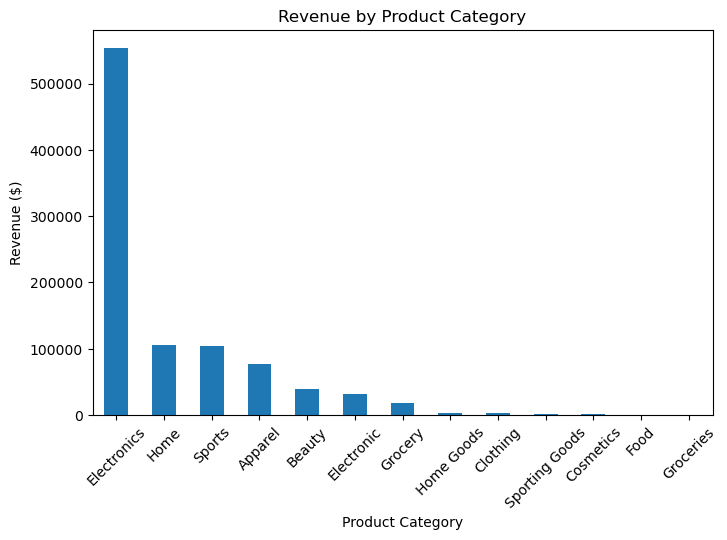

In [336]:
revenue_category = (
    analysis.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
revenue_category.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)

plt.show()

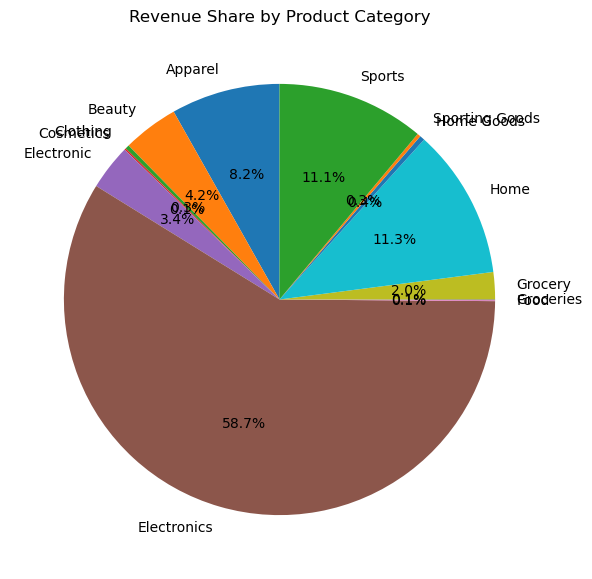

In [339]:
revenue_category = (
    analysis.groupby("product_category")["revenue"]
    .sum()
)

plt.figure(figsize=(7,7))

plt.pie(
    revenue_category,
    labels=revenue_category.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Product Category")

plt.show()

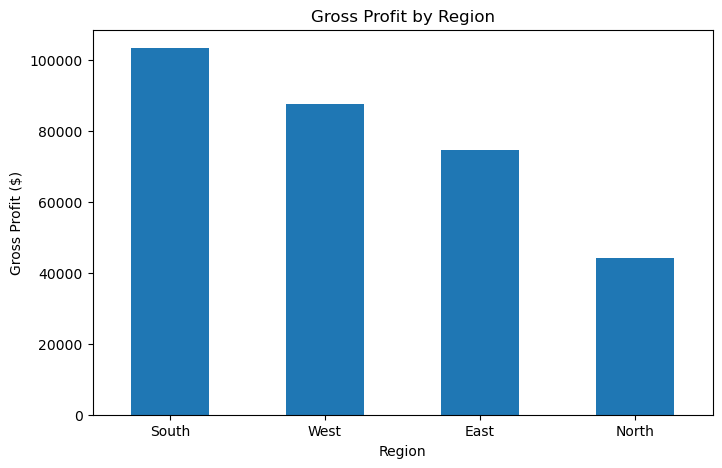

In [343]:
# Gross Profit by Region
region_profit = (
    analysis.groupby("region")["gross_profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
region_profit.plot(kind="bar")

plt.title("Gross Profit by Region")
plt.xlabel("Region")
plt.ylabel("Gross Profit ($)")
plt.xticks(rotation=0)

plt.show()